### Purpose
Creating a ML project that uses yolo, bytetrack, and rnns to create a hurricane detection & prediction algorithm that could detect hurricanes based on infrared footage and accurately predict their future pathing

###How the Algorithm Will Work
YOLO (you only look once) model will initially detect when a hurricane forms
ByteTrack algorithm will output the number of hurricanes it detects, their size, and their relative velocities
A many to many RNN will take that data and use it predict the pathing of the hurricane and potentially when the hurricane disappears

###Creating the Dataset
All footage of hurricanes (that are infrared, ~15 minutes, long year-round) will be recorded from weather.gov’s redirect links. To get the data, I will be using the yt-dlp command to download the redirect links in a mp4 format. In addition, NodeJS 22 will be the javascript runtime environment to resolve the issues   

After that, I would upload the footage to roboflow and manually splice the footage and draw the bounding boxes. (I'm fully aware that there is an AI assistent that could help me, but unfortunately, it didn't perform well in my case).

###Videos Used In the Training Set
* 2024 — https://youtu.be/w2MM7BIpqYY
* 2023 — https://youtu.be/ANb9AQYFA94
* 2022 — https://youtu.be/hTmjRqykmdM
* 2021 — https://youtu.be/2yb0Ra5AZHs
* 2020 — https://youtu.be/Lthy2r_91_Q
* 2019 — https://youtu.be/XHHQEByoeCo

###Dataset and Image Detection Module

In total, my dataset contains 553 images with a 70/20/10 split on the training, validation, and test set. Thanks to Roboflow's automatic training features, this module has very solid performance:
* mAP@50 -- 93.1%
* Precision -- 85.2%
* Recall -- 88.2%
* F1 -- 86.7%

After that, I created a simple workflow with Yolo26 for image detection and ByteTrack Tracker for object ids & tracking images across frames, an essential feature for the prediction part of this project.


The workflow looks something like this. For this project, the image output will be mostly ignored.
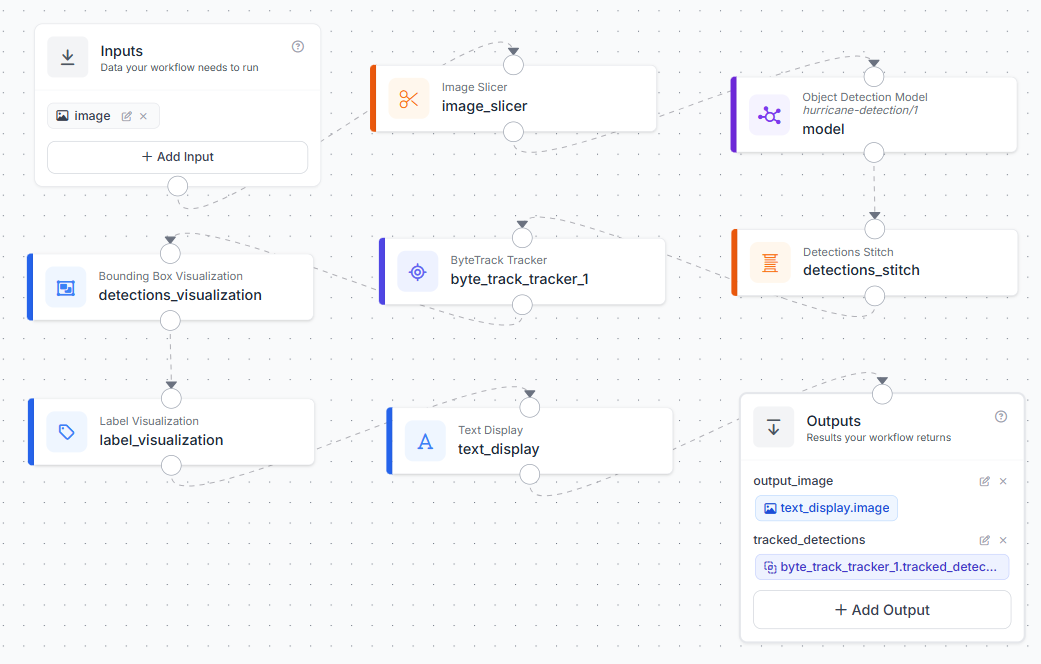

###Class for downloading videos from YT

In [ ]:
#class for downloading video dependencies
class video_downloader():

  def __init__(self, urls):
    self.urls = urls

  #downloads external dependencies
  def install_dependencies():
    !pip install yt-dlp

    !apt-get update
    !curl -fsSL https://deb.nodesource.com/setup_22.x | sudo -E bash -
    !sudo apt install -y nodejs

  #checks dependencies
  #make sure to have node 22+ (because that is what yt-dlp is compatible with)
  def check_dependencies():
    !yt-dlp --version
    !node -v

  #automates the downloading of videos using the stored links
  def download_videos(self, urls=None):
    if urls == None:
      urls = self.urls

    for url in urls:

      #first argument of the command is what url it is downloading
      #second argument is the used javascript runtime
      #third argument is the final merged format
      #fourth argument is to use the external javascript challenge solver script
      !yt-dlp "{url}" --js-runtimes node --merge-output-format mp4 --remote-components ejs:github

###Procedure For Downloading the YT Videos

In [ ]:
urls = ["https://youtu.be/w2MM7BIpqYY",
        "https://youtu.be/ANb9AQYFA94",
        "https://youtu.be/hTmjRqykmdM",
        "https://youtu.be/2yb0Ra5AZHs",
        "https://youtu.be/Lthy2r_91_Q",
        "https://youtu.be/XHHQEByoeCo"]

#installs and checks video downloading section of the project
downloader = video_downloader(urls)

downloader.install_dependencies()
downloader.check_dependencies()

In [ ]:
#downloading the videos
downloader.download_videos()

###Processor For Video Footage

Unfortunately, downloading weights from Roboflow would cost me a mind-boggling $99/month. Thus, I did the next best thing of deploying the model as an API. How the following code will work is that it will take a video file, split it into images, send the images to the roboflow workflow, and return dat such as bounding boxes.

In [ ]:
#downloaing dependnecies
!pip install inference opencv-python supervision

In [ ]:
#code for how the data will be fed to roboflow

import numpy as np
import pandas as pd
import json
import supervision as sv
from inference import InferencePipeline

#class for tracking images across frames
class ImageTracker:

    def __init__(self, info):
        self.WORKSPACE_NAME = info["WORKSPACE_NAME"]
        self.WORKFLOW_ID = info["WORKFLOW_ID"]
        self.ROBOFLOW_API_KEY = info["ROBOFLOW_API_KEY"]
        self.samples_list = [] # Temporary storage for samples
        self.df = pd.DataFrame() # Final DataFrame will be built from samples_list

    def process_prediction(self, predictions, video_frame):
        """
        Callback function for the Inference Pipeline.
        Note the inclusion of 'self' so we can access instance state safely.
        """
        # Ensure this matches the block name in your Roboflow Workflow UI
        tracked_detections = predictions.get("tracked_detections", [])

        for obj in tracked_detections:
            sample = {}

            sample["hurricane_id"] = obj.get("tracker_id")
            sample["x"] = obj.get("x")
            sample["y"] = obj.get("y")
            sample["width"] = obj.get("width")
            sample["height"] = obj.get("height")
            sample["confidence"] = obj.get("confidence")
            sample["frame_number"] = video_frame
            sample["alive"] = 1

            self.samples_list.append(sample)

    def startPipeline(self, video_path):
        """Initializes and runs the pipeline, returning the final structured array."""

        self.samples_list = [] # Reset samples for a new pipeline run

        pipeline = InferencePipeline.init_with_workflow(
            api_key=self.ROBOFLOW_API_KEY,
            workspace_name=self.WORKSPACE_NAME,
            workflow_id=self.WORKFLOW_ID,
            video_reference=video_path,
            image_input_name="image",
            max_fps=30,
            on_prediction=self.process_prediction, # Python handles binding 'self' automatically here
        )

        pipeline.start()
        pipeline.join() # Wait until video completes processing

        # Convert the collected samples into a DataFrame
        cols = ["hurricane_id",
                "x",
                "y",
                "width",
                "height",
                "frame_number",
                "confidence",
                "alive"]
        self.df = pd.DataFrame(self.samples_list, columns=cols)

        detection_results = self.df

        return detection_results

###Random Data Values

These values are for testing & debugging the training and prediction workflows only.

In [ ]:
import pandas as pd
import numpy as np

rng = np.random.default_rng()

test_data = rng.integers(0, 10, size=(100, 7))
# Ensure 'alive' column is binary (0 or 1) for BCELoss target
test_data[:, 6] = rng.integers(0, 2, size=(100,))
df = pd.DataFrame(data=test_data, columns=['hurricane_id', 'frame_number', 'x','y','width','height','alive'])

print(df)

    hurricane_id  frame_number  x  y  width  height  alive
0              3             8  8  7      0       2      0
1              3             8  8  3      9       5      1
2              5             1  8  9      4       0      1
3              8             1  9  1      8       8      0
4              7             4  9  6      5       8      0
..           ...           ... .. ..    ...     ...    ...
95             8             8  7  7      7       2      0
96             1             2  2  5      5       3      1
97             0             6  7  4      1       2      0
98             6             4  3  7      1       2      1
99             7             8  9  6      2       5      0

[100 rows x 7 columns]


###Image Processing Procedure

Basically, this cell converts any video into frames that will be fed into the roboflow workflow. That workflow would return the bounding box data that will be converted into a dataframe for efficient operations

In [ ]:
info = {
    "WORKSPACE_NAME" : "hellos-workspace-burae",
    "WORKFLOW_ID" : "small-object-detection-sahi",
    "ROBOFLOW_API_KEY" : "1KJPQjCgoo3kfREPtQ9D"
}

image_processor = ImageTracker(info)

video_path = ''

df = image_processor.startPipeline(video_path)

### Sliding Window for RNN Data Preparation

To prepare the data for a Recurrent Neural Network (RNN), we need to transform the time-series data into sequences. An RNN processes data sequentially, where each prediction depends on the previous inputs. The sliding window technique is commonly used for this:

1.  **Input Sequence (X)**: We define a `sequence_length` (e.g., 5 frames). For each hurricane, we take a window of `sequence_length` consecutive frames as input.
2.  **Target Sequence (y)**: Corresponding to each input sequence, we define a `prediction_horizon` (e.g., 1 frame). The target for the input sequence will be the `prediction_horizon` number of frames *immediately following* the input sequence.

This function will iterate through each `hurricane_id` in your DataFrame, applying this sliding window to create a dataset suitable for training your RNN. We'll be predicting the next `prediction_horizon` elements based on the `sequence_length` preceding elements.

In addition to the AI generated code, I made two adjustment. One, if there are less than 5 frames for an identified hurricane, the data will be discarded (since it's likely noise). Two, if there are less data in the prediction than the prediction horizon, I the prediction tensor with zeros (perfectly acceptable in my use case).

In [ ]:
def create_sequences(df, sequence_length, prediction_horizon, features, target_features):
    X, y = [], []
    for hurricane_id in df['hurricane_id'].unique():
        hurricane_df = df[df['hurricane_id'] == hurricane_id].sort_values(by='frame_number')

        if len(hurricane_df) < sequence_length:
          continue

        data = hurricane_df[features].values
        targets = hurricane_df[target_features].values

        for i in range(len(hurricane_df) - sequence_length - prediction_horizon + 1):
            X.append(data[i:(i + sequence_length)])
            y.append(targets[(i + sequence_length):(i + sequence_length + prediction_horizon)])

        if len(y) < prediction_horizon:
            y.append(np.zeros((prediction_horizon-len(y), len(target_features))))

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

### DataLoader Class

In [ ]:
import torch
from torch.utils.data import Dataset

# different from CNN which uses ImageFolder method, we don't have such method for RNN, so we need to write the dataset class ourselves, reference tutorial is in the main documentation
class HurricaneDataset(Dataset):
    def __init__(self, train_x, train_y):
        super(Dataset, self).__init__()
        # Expecting train_x and train_y to already be torch.Tensors
        self.x = train_x
        self.y = train_y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

###Data Processing Procedure

These cells will be responsible for splitting and loading data into DataLoaders to efficiently train the class.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sequence_length = 5
prediction_horizon = 3 # Number of future frames to predict

# Define the features to be used for input (X) and target (y)
# For simplicity, let's use x, y, width, height as features
# and predict the next x, y, width, height
features = ['x', 'y', 'width', 'height', 'alive']

# Create sequences from the processed DataFrame
X, y = create_sequences(df, sequence_length, prediction_horizon, features, features)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target sequences): {y.shape}")

Shape of X (input sequences): torch.Size([31, 5, 5])
Shape of y (target sequences): torch.Size([31, 3, 5])


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = HurricaneDataset(train_x, train_y)
test_dataset = HurricaneDataset(test_x, test_y)

# now prepare the dataloader for training set and evaluation set, and hyperparameters
batch_size = 5

train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=2)

test_loader = DataLoader(test_dataset,
                         batch_size = batch_size,
                         shuffle=False,
                         num_workers=2)


###RNN

As you can tell below, this isn't an ordinary RNN. For this portion of the project, I'd like the RNN to predict both the future path of the hurricane and if the hurricane is dead or alive. (Initially, I planned to simply have the RNN predict [0,0,0,0] to signify a dead hurricane. However, I was advised against this since a change from say 40px to 0px width would probably cause an exploding gradient that messes up my model).

To make things efficient, this RNN will be a multi-task model that outputs a tuple (binary dead/alive, tensor on bounding boxes). There will be two heads: a binary classification one with sigmoid and regression. The former is responsible for predicting whether the hurricane would be alive, and the latter will predict the bounding box dimensions.

In [ ]:
import torch.nn as nn

# model design goes here
class RNN(nn.Module):

    # there is no "correct" RNN model architecture for this lab either, you can start with a naive model as follows:
    def __init__(self, input_feature_size, hidden_size, num_layers, prediction_horizon):
        super(RNN, self).__init__()

        self.prediction_horizon = prediction_horizon
        self.lstm = nn.LSTM(input_size=input_feature_size,
                            hidden_size = hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        self.linear1 = nn.Linear(in_features=hidden_size, out_features=256)

        #predicts the if the next 'prediction_horizon' steps will be alive or not
        self.linear2 = nn.Linear(in_features=256, out_features=self.prediction_horizon)

        #predicts the bounding box information for 'prediction_horizon' steps
        self.linear3 = nn.Linear(in_features=256, out_features=self.prediction_horizon * 4)


    def forward(self, x):
        out, hidden = self.lstm(x)
        out = out[:, -1, :]
        out = self.linear1(out)
        out = self.relu(out)

        #responsible for outputting dead or alive hurricane (probabilities)
        binary_pred = self.linear2(out)
        binary_pred = self.sigmoid(binary_pred)

        #responsible for predicting bounding boxes, reshaped for multi-step prediction
        bounding_pred = self.linear3(out)
        bounding_pred = bounding_pred.view(-1, self.prediction_horizon, 4)

        return (binary_pred, bounding_pred)

###Masked Multipliers Class

The class serves two purposes: a custom loss function for our rnn and holding two parameters that act as multipliers for the two losses. As standard, MSE loss will be used for the regression portion and BCE loss will be used for the binary classification portion. The tricky part is how to combine these losses to make sense. The algorithm used in this class is described in this paper about multi-task models: https://arxiv.org/pdf/1705.07115.

As stated in the paper, since these results come from different distributions (bernolli and gaussian), it's possible that the results output different ranges. If these ranges are unbalanced for, one distribution is going to contribute a lot more to the loss function and affect backpropagation. To compensate, one could use an approach to weigh and aggregate the loss values: e.g., a * bce-loss + b * mse-loss.

Finding such values a & b manually would be tedious. Also, using a model to find them wouldn't be ideal because said model could easily cheat the system by setting a & b to 0 or a negative value.

Thus, they proposed the following loss function: 1/(2sigma$^2_1$)L$_1$(W) + 1/(sigma$^2_2$)L$_2$(W) + log(sigma$_1$) + log(sigma$_2$).
* L$_1$(W) -- euclidean loss
* L$_2$(W) -- cross entropy loss
* a = log(sigma$^2_1$)
* b = log(sigma$^2_2$)
* sigma$^2$ = exp(a) or exp(b)
* log(sigma) = 0.5a or 0.5b

Thus, for the code, it converts a & b into
* 1/exp(-a) + 0.5*a
* 1/exp(-b) + 0.5*b

Although one could try to optimize for sigma directly instead of something like s = log(sigma$^2_1$), the paper stated that in practice, it is best to optimize for s = log(sigma$^2_1$) because it is more stable.

In this equation, it would be impossible for the model to cheat either sigma values (by setting them to zero or any small number) bc/ either the 1/(sigma$^2$) or log(sigma) parts of the equation would increase the loss dramatically.

Generally speaking, one can construct these custom loss functions through the following steps:
* use the appropriate loss function (MSE for regression, BCE for binary classification, and CE for multi classification)
* allocating a parameter to the loss, and applying
* create the loss equation using the following equation

$TotalLoss = sum_{i=1 to N} (C_i * exp(-s_i) * L_i(W) + 0.5 * s_i)$
* $L_i(W)$ -- output of the loss function
* s_i -- loss multiplier
* C_i -- constant factor (0.5 for classification & 1.0 for classification)

After computing the loss, we could call .backwards() on it like any other loss function output because PyTorch's autograd system would correct the gradients for us.


In [ ]:
class MaskedMultiTaskLoss(nn.Module):
    def __init__(self):
        super(MaskedMultiTaskLoss, self).__init__()

        # HERE THEY ARE: Two trainable internal parameters initialized at 0.0
        # PyTorch tracks these exactly like it tracks neural network weights!
        self.log_vars = nn.Parameter(torch.zeros(2))

        self.mse = nn.MSELoss(reduction='none') # Per-element MSE so we can mask it
        self.bce = nn.BCELoss()

    def forward(self, pred_active, pred_bbox, true_active, true_bbox):
        # Step A: Raw Classification Loss
        loss_class = self.bce(pred_active, true_active)

        # Step B: Masked Raw Regression Loss
        raw_mse_loss = self.mse(pred_bbox, true_bbox)

        # Expand true_active to match the dimensions of raw_mse_loss for element-wise multiplication
        # true_active was (batch_size, prediction_horizon), now becomes (batch_size, prediction_horizon, 1)
        # then expanded to (batch_size, prediction_horizon, 4)
        expanded_true_active = true_active.unsqueeze(-1).expand_as(raw_mse_loss)
        masked_mse_loss = raw_mse_loss * expanded_true_active # Erase loss if storm is dead

        loss_reg = masked_mse_loss.mean()

        # Step C: The Multipliers Come Into Play!
        # Convert log_vars to precision multipliers (1 / sigma^2)
        precision1 = torch.exp(-self.log_vars[0]) # Multiplier for Regression
        precision2 = torch.exp(-self.log_vars[1]) # Multiplier for Classification

        # We multiply the individual losses by our dynamic multipliers
        # and append the log penalty terms to prevent cheating.
        total_loss = (0.5 * precision1 * loss_reg) + \
                     (precision2 * loss_class) + \
                     (0.5 * self.log_vars[0]) + \
                     (0.5 * self.log_vars[1])

        return total_loss

###Model Training Procedure

Our MaskedMultiTaskLoss is our loss function. As for the optimizer, the standard Adam should be good enough. An importants step is to pass in parameters from both our loss and rnn model to ensure all parameters are properly optimized. The rest of the code is just a standard training loop.

In [ ]:
from torch.optim import Adam

hidden_size = 256
num_layers = 2
learning_rate = 0.001

# instantiate your rnn model and move to device as in cnn section
rnn = RNN(5, hidden_size, num_layers, prediction_horizon).to(device) # Pass prediction_horizon
criterion = MaskedMultiTaskLoss()

# you can start with using Adam as optimizer as well
all_trainable_parameters = list(rnn.parameters()) + list(criterion.parameters())
optimizer = torch.optim.Adam(all_trainable_parameters, lr=learning_rate)

In [ ]:
epoch_size = 10

# start training
rnn.train()
for epoch in range(epoch_size): # start with 10 epochs

    loss = 0.0 # you can print out average loss per batch every certain batches

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # get inputs and target values from dataloaders and move to device
        inputs = inputs.to(device)
        targets = targets.to(device)

        # forward -> compute loss -> backward propogation -> optimize (see tutorial mentioned in main documentation)
        optimizer.zero_grad()

        # 1. Run the forward pass through the model to get predictions
        pred_active, pred_bbox = rnn(inputs)

        true_active = targets[:,:,4]
        true_bbox = targets[:,:,:4]

        # Removed debug print statements as issue is addressed.

        batch_loss = criterion(pred_active, pred_bbox, true_active, true_bbox)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss# add loss for current batch
        if batch_idx % 100 == 99:    # print average loss per batch every 100 batches
            print(f'[{epoch + 1}, {batch_idx + 1:5d}] loss: {loss / 100:.3f}')
            loss = 0.0

print('Finished Training')

Finished Training


###Model Evaluation Procedure

Since the results should come from data distributions, I've decided to evaluate the results seperately using the standard approaches for both: r2 score for the regression portion and accuracy_score for the binary classification portion.

In [ ]:
binary_pred_list = [] # Renamed to avoid conflict with function output
binary_truth_list = []

reg_pred_list = [] # Renamed
reg_truth_list = []

# evaluation
rnn.eval()
with torch.no_grad():
    for (inputs, targets) in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Extract true_active and true_bbox directly from targets
        true_active_batch = targets[:, :, 4] # Shape: (batch_size, prediction_horizon)
        true_bbox_batch = targets[:, :, :4]  # Shape: (batch_size, prediction_horizon, 4)

        # Get model predictions
        pred_active_batch, pred_bbox_batch = rnn(inputs)

        # Move to CPU and convert to numpy for collection
        binary_pred_list.append(pred_active_batch.detach().cpu().numpy().reshape(-1)) # pred_active is already (batch_size, prediction_horizon)
        binary_truth_list.append(true_active_batch.detach().cpu().numpy().reshape(-1))

        reg_pred_list.append(pred_bbox_batch.detach().cpu().numpy().reshape(-1, 4)) # pred_bbox is already (batch_size, prediction_horizon, 4)
        reg_truth_list.append(true_bbox_batch.detach().cpu().numpy().reshape(-1, 4))


In [ ]:
from sklearn.metrics import r2_score, accuracy_score

# Concatenate all collected data
binary_pred = np.concatenate(binary_pred_list)
binary_truth = np.concatenate(binary_truth_list)

reg_pred = np.concatenate(reg_pred_list)
reg_truth = np.concatenate(reg_truth_list)

# For accuracy, threshold the probabilities to get binary predictions (0 or 1)
binary_pred_thresholded = (binary_pred > 0.5).astype(int)

# Use r2_score from sklearn for bounding box regression
r2score = r2_score(reg_truth, reg_pred)
print(f"Performance of the bbox portion (R2 Score): {r2score:.4f}")

# Use accuracy_score from sklearn for binary classification
accuracy = accuracy_score(binary_truth, binary_pred_thresholded)
print(f"Performance of the binary portion (Accuracy): {accuracy:.4f}")


Performance of the bbox portion (R2 Score): -0.1546
Performance of the binary portion (Accuracy): 0.7619


The above results you see are the workflow on the randomly generated dataset. My intent was to check for any bugs before handling the real data. These results are expected

###Limitations
A major limitation about ML is that it’s very difficult for models to adapt to changing conditions. Thus, as global temperatures continue to rise, it’s possible that the RNN cannot keep up with these changes: leading to inaccurate predictions.

The model was trained on data from weather.gov, and several aspects of the data limit this system’s practicality: infrared only footage, specific angle of the footage, and limited footage. The videos are infrared, meaning that none-infrared data could lead to inaccurate predictions & detections. All of this footage is of one angle over the Atlantic Ocean. Consequently, predictions of hurricanes will only be accurate over this angle over the Atlantic Ocean specifically. I highly doubt that this model could predict storms in the Pacific or Indian Ocean well. Finally, this site only has data between 1978 and 2024. While that should be plenty for this project, a much larger dataset would improve accuracy significantly.

1978 and 2024’s global climates are very different, due to global warming. This variation could have skewed data distribution: leading to inaccurate predictions.

###Suggestions/Enhancements for Future Iterations of this Project
Maybe between sending the DeepSort algorithm to the GRU, adjust the data so that the coordinates represent global coordinates instead of just coordinates on the image. This way, it could be possible for the model to detect and predict tropical storms globally instead of just over the Atlantic Ocean. In addition, feeding additional data like the temperature or air pressure of the Atlantic Ocean could help the GRU’s accuracy.

Train the YOLO and Deepsort model using more slowed down data. The videos fed to these models are sped up footage that compresses one year’s worth of data into a span of 15 minutes. While this means that training the models are easier, this model could be highly impractical. As we all know, actual footage of hurricanes wouldn’t be nearly as fast. Thus, training the YOLO and Deepsort components of this system should lead to a more practical model.
